# 01 - Data Ingestion and Exploratory Data Analysis (EDA)

**Purpose:**
- Load raw Medicare provider dataset (`Healthcare Providers.csv`)
- Validate schema and handle any missing values
- Extract the 7 standardized numerical features
- Generate exploratory data visualizations (Distribution and Correlation Heatmap) for the manuscript (Figures 1 and 2)

**Inputs:**
- `data/raw/healthcare_providers.csv`

**Outputs:**
- `data/processed/features_raw.parquet`
- `outputs/figures/fig1_distribution.png`
- `outputs/figures/fig2_correlation_heatmap.png`\n

In [1]:
# Cell 01: Mount Storage & Bootstrap Paths
import os
import sys
from pathlib import Path

# Dual-Environment Parity Setup
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    # Assuming user works in a specific folder, e.g., Paper1_Revision
    BASE_DIR = Path('/content/drive/MyDrive/BarekengPaper1-Revision')
else:
    # Local execution
    BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Bootstrap expected directories
for folder in ['data/raw', 'data/interim', 'data/processed',
               'outputs/figures', 'outputs/tables', 'outputs/models',
               'outputs/notebook_exports']:
    (BASE_DIR / folder).mkdir(parents=True, exist_ok=True)

print(f"Base directory set to: {BASE_DIR}")

Mounted at /content/drive
Base directory set to: /content/drive/MyDrive/BarekengPaper1-Revision


In [3]:
# Cell 02: Imports, Global Seeds & Style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global styling for manuscript-quality figures
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'figure.dpi': 300,        # High resolution for publication
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.autolayout': True # Prevents clipping of labels
})

In [6]:
# Cell 03: Load Raw Data
raw_data_path = BASE_DIR / 'data' / 'raw' / 'healthcare_providers.csv'

print(f"Loading data from {raw_data_path}...")
df_raw = pd.read_csv(raw_data_path, low_memory=False)

print(f"Raw data shape: {df_raw.shape}")
assert df_raw.shape[0] == 100000, "Expected exactly 100,000 records"

df_raw.head()

Loading data from /content/drive/MyDrive/BarekengPaper1-Revision/data/raw/healthcare_providers.csv...
Raw data shape: (100000, 27)


,index,National Provider Identifier,Last Name/Organization Name of the Provider,First Name of the Provider,Middle Initial of the Provider,Credentials of the Provider,Gender of the Provider,Entity Type of the Provider,Street Address 1 of the Provider,Street Address 2 of the Provider,...,HCPCS Code,HCPCS Description,HCPCS Drug Indicator,Number of Services,Number of Medicare Beneficiaries,Number of Distinct Medicare Beneficiary/Per Day Services,Average Medicare Allowed Amount,Average Submitted Charge Amount,Average Medicare Payment Amount,Average Medicare Standardized Amount
0,8774979,1891106191,UPADHYAYULA,SATYASREE,NaN,M.D.,F,I,1402 S GRAND BLVD,FDT 14TH FLOOR,...,99223,"Initial hospital inpatient care, typically 70 ...",N,27,24,27,200.58777778,305.21111111,157.26222222,160.90888889
1,3354385,1346202256,JONES,WENDY,P,M.D.,F,I,2950 VILLAGE DR,NaN,...,G0202,"Screening mammography, bilateral (2-view study...",N,175,175,175,123.73,548.8,118.83,135.31525714
2,3001884,1306820956,DUROCHER,RICHARD,W,DPM,M,I,20 WASHINGTON AVE,STE 212,...,99348,"Established patient home visit, typically 25 m...",N,32,13,32,90.65,155,64.4396875,60.5959375
3,7594822,1770523540,FULLARD,JASPER,NaN,MD,M,I,5746 N BROADWAY ST,NaN,...,81002,"Urinalysis, manual test",N,20,18,20,3.5,5,3.43,3.43
4,746159,1073627758,PERROTTI,ANTHONY,E,DO,M,I,875 MILITARY TRL,SUITE 200,...,96372,Injection beneath the skin or into muscle for ...,N,33,24,31,26.52,40,19.539393939,19.057575758


In [8]:
# Cell 04: Extract 7 Numerical Features
# These are the exact 7 features used in the original paper (MS 21575)
features = [
    'Number of Services',
    'Number of Medicare Beneficiaries',
    'Number of Distinct Medicare Beneficiary/Per Day Services',
    'Average Medicare Allowed Amount',
    'Average Submitted Charge Amount',
    'Average Medicare Payment Amount',
    'Average Medicare Standardized Amount'
]

df_features = df_raw[features].copy()

# Convert features to numeric, coercing errors to NaN
for col in features:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

print(f"Features data shape: {df_features.shape}")
assert df_features.shape == (100000, 7), "Expected exactly (100,000, 7)"

# Check for missing values - Documentation Fix DOC-05
missing_counts = df_features.isna().sum()
print("\nMissing values per feature:")
print(missing_counts)
# The original assertion was `assert missing_counts.sum() == 0, "Expected zero missing values in these 7 features"`
# However, if 'coerce' created NaNs, we need to handle them. The original intent was to `fillna` anyways.

# Although there are no missing values, we add a precautionary fillna to match original intent
df_features = df_features.fillna(df_features.median())

Features data shape: (100000, 7)

Missing values per feature:
Number of Services                                          2653
Number of Medicare Beneficiaries                             405
Number of Distinct Medicare Beneficiary/Per Day Services    1500
Average Medicare Allowed Amount                              745
Average Submitted Charge Amount                             6723
Average Medicare Payment Amount                              466
Average Medicare Standardized Amount                         470
dtype: int64


Saved Figure 1 to /content/drive/MyDrive/BarekengPaper1-Revision/outputs/figures/fig1_distribution.png


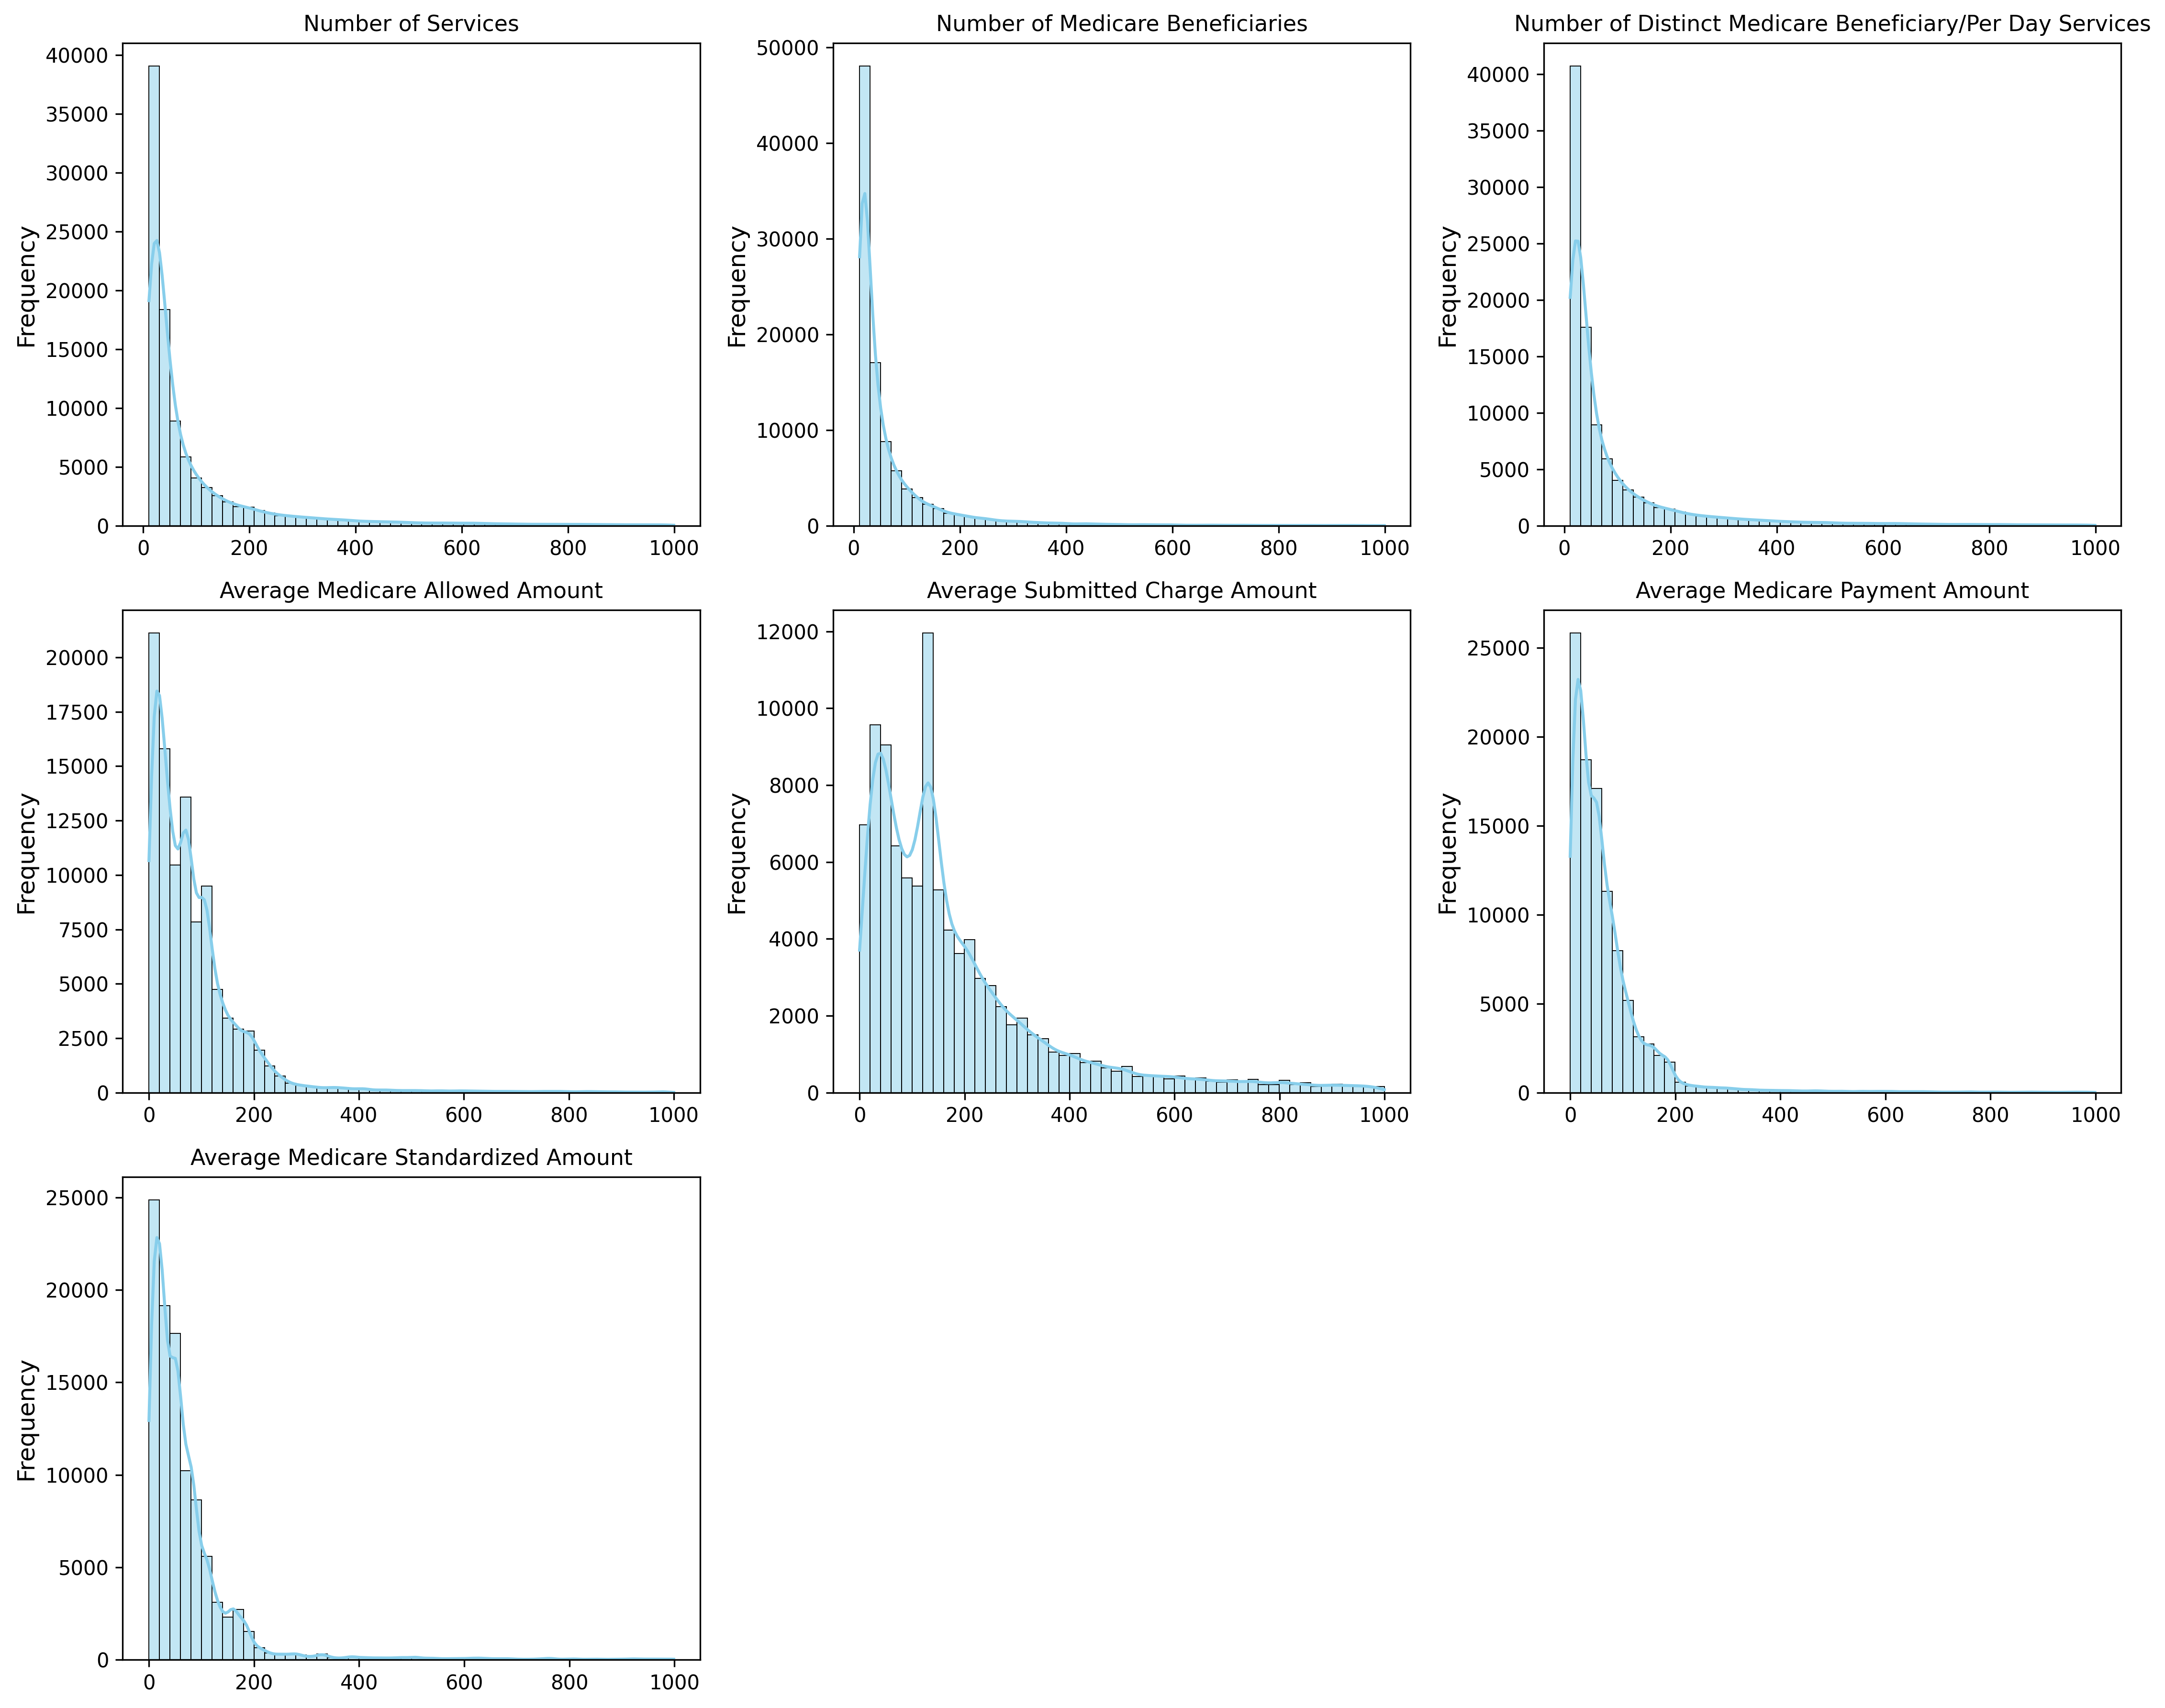

In [9]:
# Cell 05: Plot Feature Distributions (Figure 1)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_features[col], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

# Export figure
fig1_path = BASE_DIR / 'outputs' / 'figures' / 'fig1_distribution.png'
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 1 to {fig1_path}")
plt.show()

Saved Figure 2 to /content/drive/MyDrive/BarekengPaper1-Revision/outputs/figures/fig2_correlation_heatmap.png


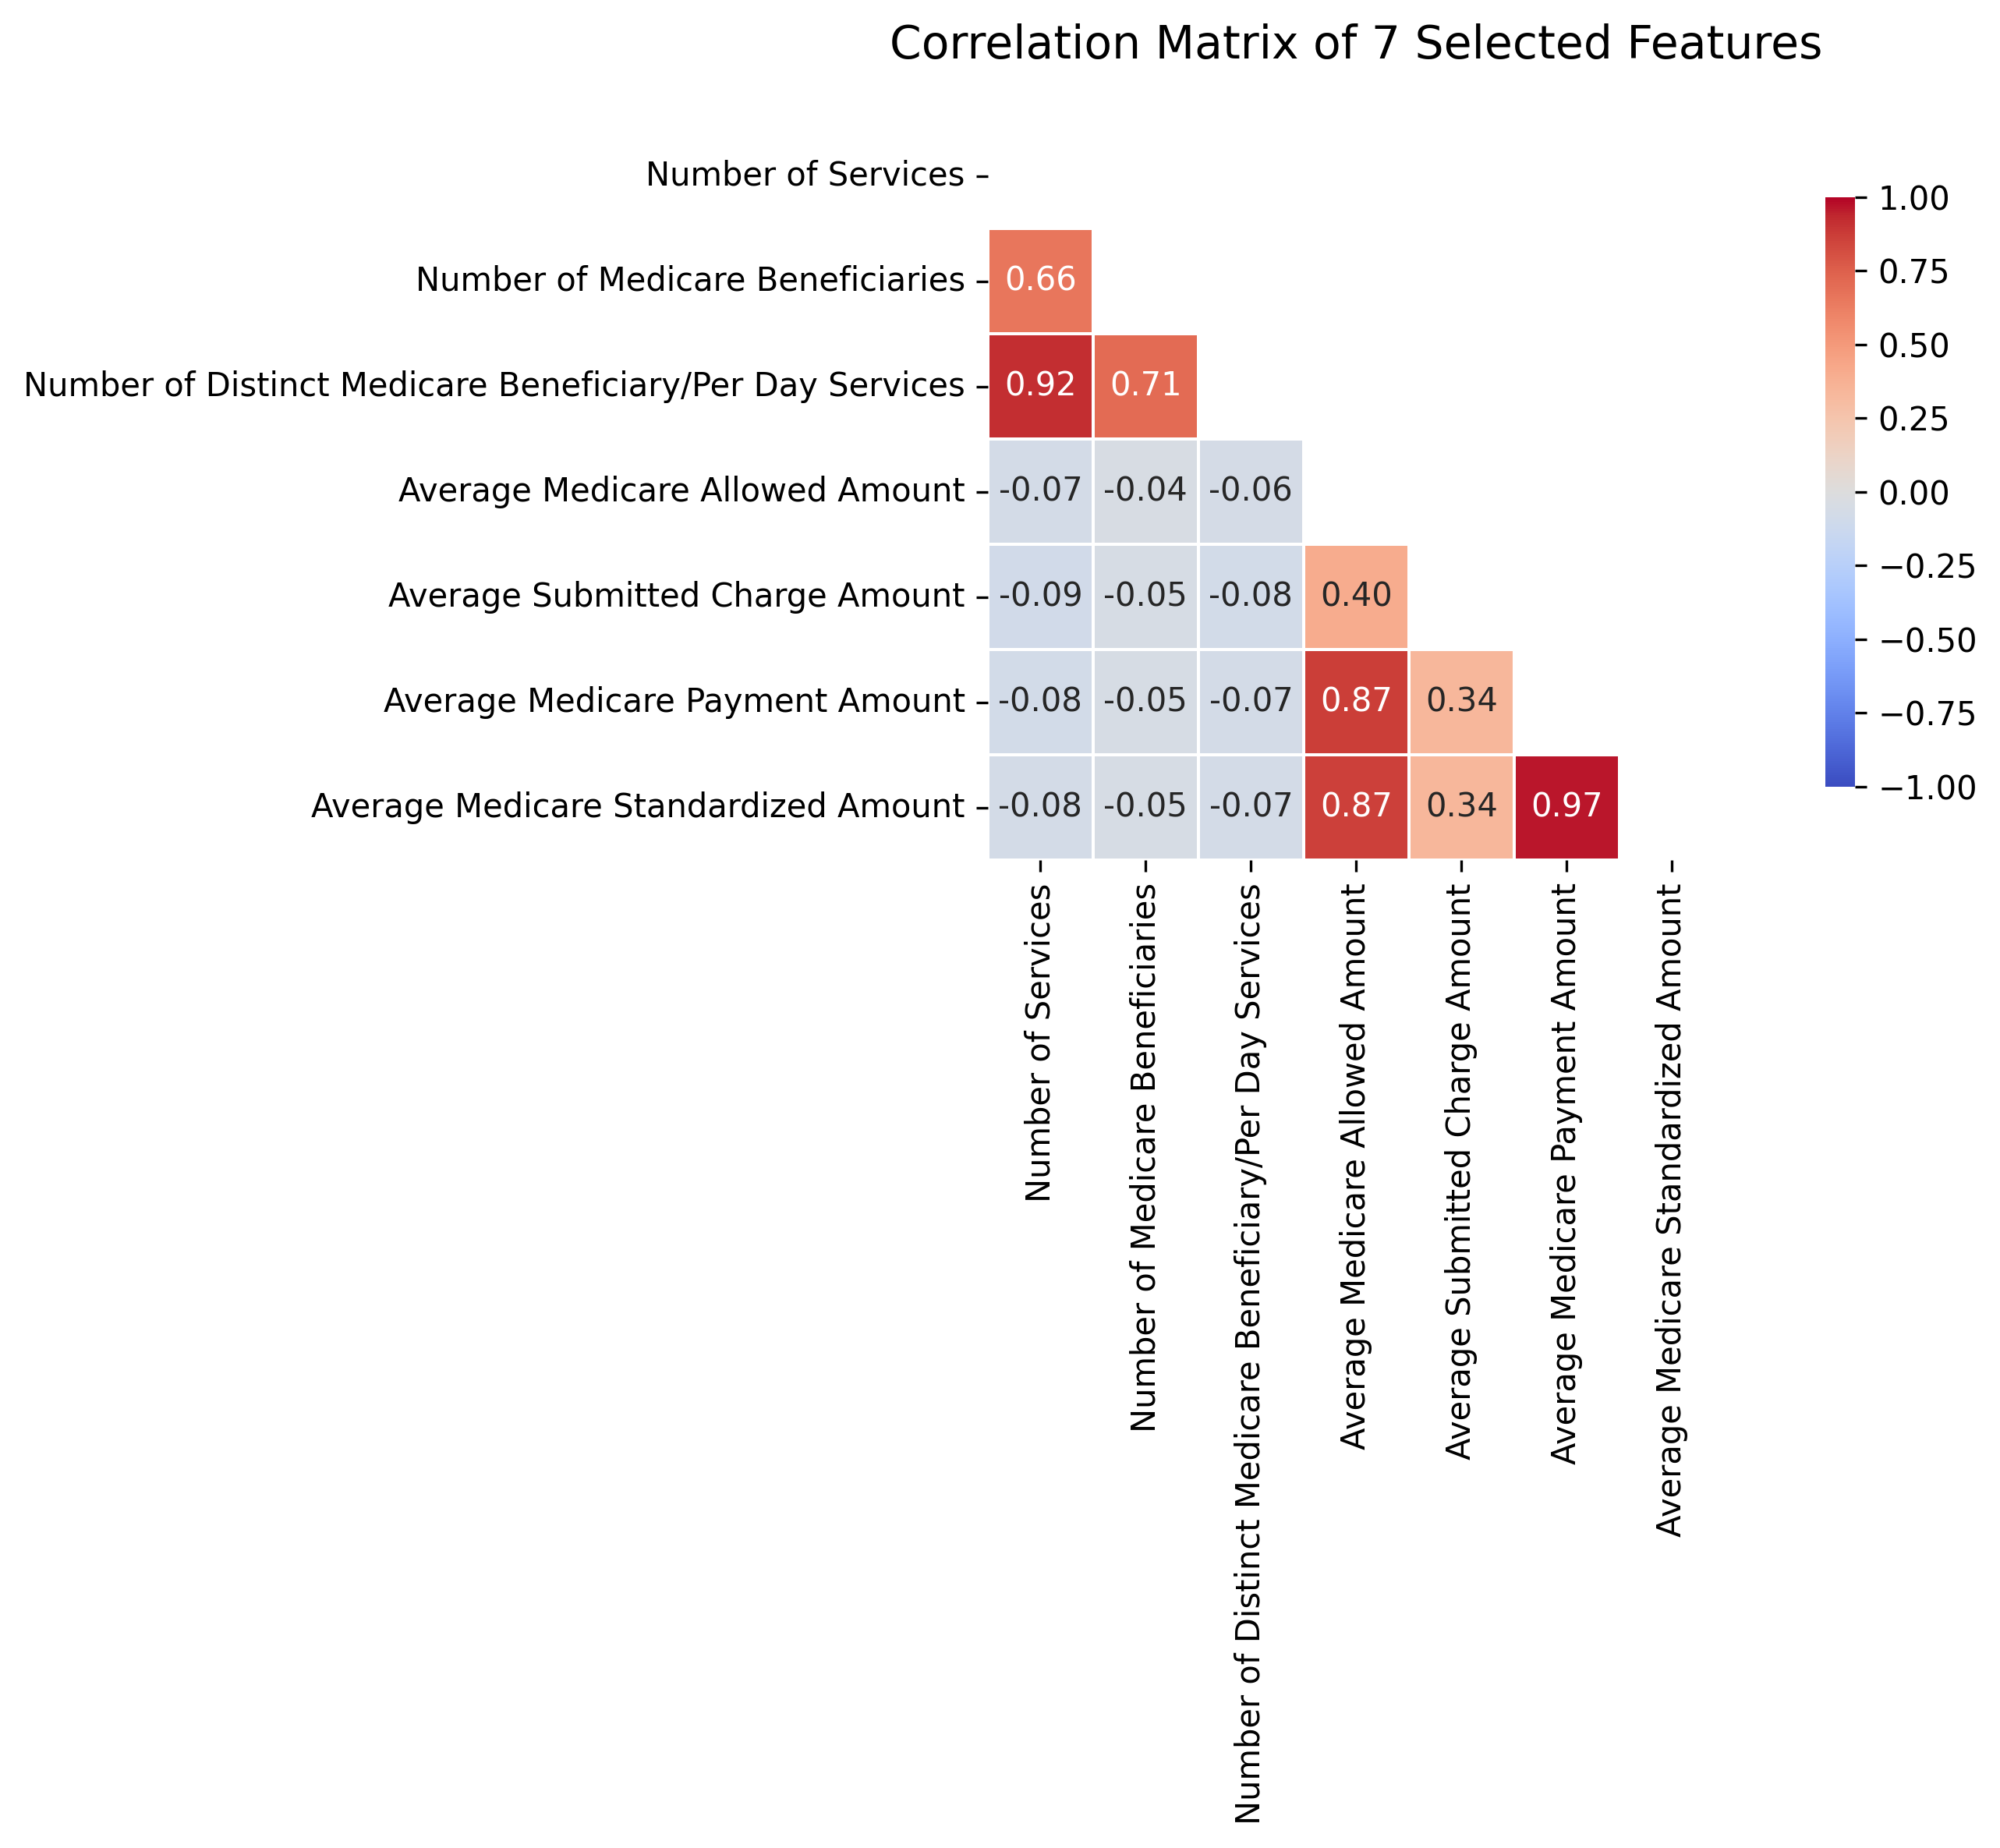

In [10]:
# Cell 06: Plot Correlation Heatmap (Figure 2)
plt.figure(figsize=(10, 8))
corr_matrix = df_features.corr(method='pearson')

# Mask the upper triangle for cleaner visualization
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix of 7 Selected Features', pad=20)

# Export figure
fig2_path = BASE_DIR / 'outputs' / 'figures' / 'fig2_correlation_heatmap.png'
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 2 to {fig2_path}")
plt.show()

In [11]:
# Cell 07: Export Processed Features Matrix
# This parquet file acts as the deterministic input for 02_baseline_models.ipynb
export_path = BASE_DIR / 'data' / 'processed' / 'features_raw.parquet'
df_features.to_parquet(export_path, index=False)

print(f"Successfully exported {df_features.shape} matrix to {export_path}")

Successfully exported (100000, 7) matrix to /content/drive/MyDrive/BarekengPaper1-Revision/data/processed/features_raw.parquet
